# From a Snapshot to a Direction

## Mechanism-driven single-cell modelling

Cells are dynamical systems: they maintain states, change states, and respond to interventions. Mechanistic thinking matters because it helps us

- **understand** why a state exists;
- **predict** what happens next or after a perturbation;
- **design** an experiment or intervention that distinguishes explanations.

Omics embraces cellular complexity by measuring thousands of variables at once. But ordinary single-cell RNA sequencing destroys each cell, so it usually records only a **state snapshot**, not the law that moved the cell there.

> **Central question:** Can a population of static snapshots be turned back into a candidate trajectory—and what extra evidence is required to orient it in time?


## Goals, and route

**Prerequisites:** scatter plots, the idea of a derivative, and basic Python. No prior single-cell analysis is assumed.

By the end you should be able to separate three layers of evidence:

1. **State geometry:** where cells are in expression space.
2. **Dynamic estimate:** a model-dependent proposal for where they move next.
3. **Validation or prior:** independent or prior biological information that checks the proposed direction.

**40-minute route**

- 0–12 min — two circuits with two-group middle snapshots, then add velocity to reveal different population shifts;
- 12–20 min — where direction can come from, the neighbour assumption, and an interactive RNA-splicing clock;
- 20–33 min — real U2OS data: blind three-dimensional PCA and a local vector field;
- 33–40 min — RNA markers, held-out FUCCI, and a four-sentence evidence claim.

**AI coach rule:** ask for one hint at a time. Require the coach to label every statement as measured, inferred, assumed, or validated.


## State, dynamics, and mechanism are different claims

Let the measured cellular state be a vector

$$x=(\text{Gene 1 RNA},\text{Gene 2 RNA},\ldots).$$

A snapshot estimates where cells are distributed: $p(x)$. Dynamics asks for a velocity or transition rule. A mechanism goes further:

$$\frac{dx}{dt}=f(x,\theta,u),$$

where $\theta$ represents kinetic parameters and $u$ represents an input or perturbation.

| Evidence | Supports | Does not establish by itself |
|---|---|---|
| two clusters | two expression regimes | two attractors or a transition direction |
| ordered snapshots / local velocity | a candidate trajectory | the unique molecular mechanism |
| perturbation and return/switch behaviour | a causal, falsifiable model test | that every omitted variable is irrelevant |

A useful mechanism is therefore not merely a detailed story. It makes predictions that could be wrong.


In [1]:
from pathlib import Path
import os
import tempfile
import warnings

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "peddle-sumay-mpl-cache"),
)
os.environ.setdefault(
    "LOKY_MAX_CPU_COUNT", str(max(1, min(8, os.cpu_count() or 1)))
)

import anndata as ad
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

SEED = 20260717
rng = np.random.default_rng(SEED)
plt.rcParams.update({
    "figure.figsize": (7.2, 4.4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

def stable_interactive_output(function, controls):
    '''Keep one live figure while preserving automatic widget updates.'''
    output = widgets.Output()

    def redraw(change=None):
        parameters = {
            name: control.value
            for name, control in controls.items()
        }
        with output:
            # Immediate clearing prevents restored widget values from
            # leaving several identical Matplotlib figures visible.
            output.clear_output(wait=False)
            function(**parameters)

    for control in controls.values():
        control.observe(redraw, names="value")
    redraw()
    return output

def locate_data(filename):
    '''Find bundled data after extraction or inside the repository.'''
    filename = Path(filename).name
    cwd = Path.cwd()
    roots = [cwd, *cwd.parents]
    candidates = []
    for root in roots:
        candidates.extend([
            root / "data" / filename,
            root / "output/jupyter-notebook/"
            "02_mechanism_driven_new/data" / filename,
        ])
    # Also support launching Jupyter from the parent of the
    # extracted package directory.
    candidates.extend(cwd.glob(f"*/data/{filename}"))
    for candidate in dict.fromkeys(candidates):
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        f"Could not locate data/{filename}. Extract the complete ZIP, "
        "keep the data folder beside the notebooks, and start Jupyter "
        "from the extracted folder."
    )

BLIND_H5AD = locate_data("u2os_cell_cycle_blind.h5ad")
REVEAL_CSV = locate_data("u2os_fucci_reveal.csv.gz")
CD34_H5AD = locate_data("human_cd34_bone_marrow_blind.h5ad")
CD34_REVEAL_CSV = locate_data("human_cd34_reference_reveal.csv.gz")

print("Environment ready.")
print("Blind U2OS data:", BLIND_H5AD.name)
print("FUCCI reveal is located but will not be opened until the final section.")
print("Post-exercise CD34+ blind data:", CD34_H5AD.name)
print("CD34+ reference reveal is sealed until the final comparison.")


Environment ready.
Blind U2OS data: u2os_cell_cycle_blind.h5ad
FUCCI reveal is located but will not be opened until the final section.
Post-exercise CD34+ blind data: human_cd34_bone_marrow_blind.h5ad
CD34+ reference reveal is sealed until the final comparison.


# Part 1 — Similar middle snapshots, different mechanisms

We begin with two deliberately small gene circuits.

**Circuit 1: a mutual-repression toggle.** Gene A represses B, and B represses A:

$$
\frac{dA}{dt}=\frac{6}{1+B^4}-A,
\qquad
\frac{dB}{dt}=\frac{6}{1+A^4}-B.
$$

Cells begin near $A\approx B$. Tiny differences are amplified: some cells approach A-high/B-low, while others approach A-low/B-high. Both endpoints are stable in this model.

**Circuit 2: a driven B switch.** B activates itself and represses A:

$$
\frac{dA}{dt}=\frac{12}{1+B^4}-2A,
$$

$$
\frac{dB}{dt}=0.04+I+\frac{24B^4}{1+B^4}-4B.
$$

All cells begin A-high/B-low. Immediately after the early snapshot, a constant external driver $I=1.02$ raises B to its switching threshold. Small process fluctuations make different cells cross at different times. Once B is high, positive feedback keeps it ON and B represses A. The population therefore passes through a mixed middle phase and eventually becomes A-low/B-high.

Noise is added only in the numerical simulation; it is not another regulatory arrow in the circuit. The parameters and time units are illustrative rather than fitted to biological data.

An **attractor** is a state approached from nearby initial conditions and recovered after a small disturbance—not merely a dense cluster.


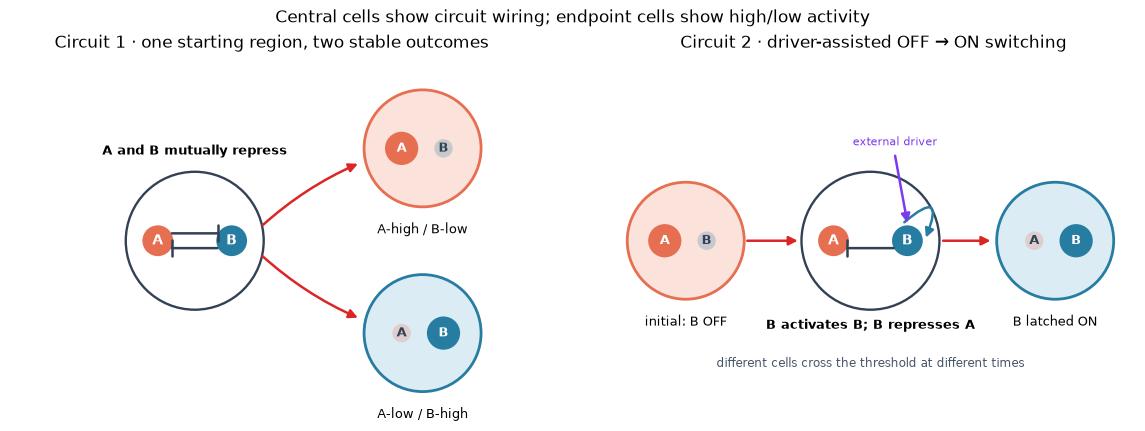

In [2]:
from matplotlib.patches import Circle, FancyArrowPatch

A_COLOR = "#e76f51"
B_COLOR = "#277da1"
A_STATE_FILL = "#fbe2db"
B_STATE_FILL = "#dcecf5"
INK = "#334155"
CELL_FILL = "#f8fafc"

def add_arrow(ax, start, end, color=INK, curve=0.0,
              arrowstyle="-|>", linewidth=1.8):
    arrow = FancyArrowPatch(
        start, end, arrowstyle=arrowstyle, mutation_scale=13,
        connectionstyle=f"arc3,rad={curve}", linewidth=linewidth,
        color=color, shrinkA=0, shrinkB=0,
    )
    ax.add_patch(arrow)

def add_repression(ax, start, end, color=INK,
                   linewidth=1.8, bar_half=0.13):
    add_arrow(ax, start, end, color=color,
              arrowstyle="-", linewidth=linewidth)
    dx, dy = end[0] - start[0], end[1] - start[1]
    length = np.hypot(dx, dy)
    nx, ny = -dy / length, dx / length
    ax.plot(
        [end[0] - bar_half * nx, end[0] + bar_half * nx],
        [end[1] - bar_half * ny, end[1] + bar_half * ny],
        color=color, linewidth=linewidth, solid_capstyle="round",
    )

def draw_state_cell(ax, center, a_high, b_high, label):
    x, y = center
    if a_high and not b_high:
        state_fill, state_edge = A_STATE_FILL, A_COLOR
    elif b_high and not a_high:
        state_fill, state_edge = B_STATE_FILL, B_COLOR
    else:
        state_fill, state_edge = CELL_FILL, INK
    ax.add_patch(Circle(center, 0.95, facecolor=state_fill,
                        edgecolor=state_edge, linewidth=2.0))
    for dx, value, color, gene in (
        (-0.34, a_high, A_COLOR, "A"),
        (0.34, b_high, B_COLOR, "B"),
    ):
        radius = 0.27 if value else 0.15
        alpha = 1.0 if value else 0.24
        ax.add_patch(Circle((x + dx, y), radius,
                            facecolor=color, edgecolor="none",
                            alpha=alpha))
        ax.text(x + dx, y, gene, ha="center", va="center",
                fontsize=9, weight="bold", color="white" if value else INK)
    ax.text(x, y - 1.20, label, ha="center", va="top", fontsize=9)

def draw_circuit_cell(ax, center, kind):
    x, y = center
    ax.add_patch(Circle(center, 1.12, facecolor="#ffffff",
                        edgecolor=INK, linewidth=1.7))
    a_xy, b_xy = (x - 0.60, y), (x + 0.60, y)
    for position, color, gene in ((a_xy, A_COLOR, "A"), (b_xy, B_COLOR, "B")):
        ax.add_patch(Circle(position, 0.25, facecolor=color, edgecolor="none"))
        ax.text(*position, gene, ha="center", va="center",
                color="white", weight="bold", fontsize=10)

    if kind == "toggle":
        add_repression(ax, (a_xy[0] + 0.23, y + 0.12),
                       (b_xy[0] - 0.23, y + 0.12))
        add_repression(ax, (b_xy[0] - 0.23, y - 0.12),
                       (a_xy[0] + 0.23, y - 0.12))
        ax.text(x, y + 1.40, "A and B mutually repress", ha="center",
                fontsize=9, weight="bold")
    elif kind == "latch":
        add_repression(ax, (b_xy[0] - 0.22, y - 0.12),
                       (a_xy[0] + 0.22, y - 0.12))
        add_arrow(ax, (b_xy[0] - 0.05, y + 0.30),
                  (b_xy[0] + 0.30, y + 0.05),
                  color=B_COLOR, curve=-2.0)
        add_arrow(ax, (x + 0.40, y + 1.38),
                  (b_xy[0], b_xy[1] + 0.29), color="#7c3aed")
        ax.text(x + 0.40, y + 1.55, "external driver", ha="center",
                fontsize=8, color="#7c3aed")
        ax.text(x, y - 1.43, "B activates B; B represses A",
                ha="center", fontsize=9, weight="bold")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.2), constrained_layout=True)

ax = axes[0]
draw_circuit_cell(ax, (3.0, 3.0), "toggle")
draw_state_cell(ax, (6.7, 4.5), True, False, "A-high / B-low")
draw_state_cell(ax, (6.7, 1.5), False, True, "A-low / B-high")
add_arrow(ax, (4.10, 3.25), (5.65, 4.25), color="#dc2626", curve=-0.08)
add_arrow(ax, (4.10, 2.75), (5.65, 1.75), color="#dc2626", curve=0.08)
ax.set_title("Circuit 1 · one starting region, two stable outcomes")

ax = axes[1]
draw_state_cell(ax, (1.2, 3.0), True, False, "initial: B OFF")
draw_circuit_cell(ax, (4.2, 3.0), "latch")
draw_state_cell(ax, (7.2, 3.0), False, True, "B latched ON")
add_arrow(ax, (2.20, 3.0), (3.02, 3.0), color="#dc2626")
add_arrow(ax, (5.38, 3.0), (6.15, 3.0), color="#dc2626")
ax.text(4.2, 0.95, "different cells cross the threshold at different times",
        ha="center", fontsize=8.5, color="#475569")
ax.set_title("Circuit 2 · driver-assisted OFF → ON switching")

for ax in axes:
    ax.set_xlim(0.0, 8.5)
    ax.set_ylim(0.3, 6.0)
    ax.set_aspect("equal")
    ax.axis("off")
fig.suptitle(
    "Central cells show circuit wiring; endpoint cells show high/low activity"
)
plt.show()


In [3]:
SNAPSHOT_TIMES = np.array([0.0, 2.7, 20.0])
SNAPSHOT_NAMES = ["early", "middle", "late"]
TRAJECTORY_STEP = 0.1
TRAJECTORY_TIMES = np.round(
    np.arange(
        SNAPSHOT_TIMES[0],
        SNAPSHOT_TIMES[-1] + 0.5 * TRAJECTORY_STEP,
        TRAJECTORY_STEP,
    ),
    10,
)
MIN_EXPRESSION = 0.004

def toggle_drift(state):
    a, b = state.T
    return np.column_stack([
        6.0 / (1.0 + b**4) - a,
        6.0 / (1.0 + a**4) - b,
    ])

def driven_drift(state, driver):
    a, b = state.T
    return np.column_stack([
        12.0 / (1.0 + b**4) - 2.0 * a,
        0.04 + driver + 24.0 * b**4 / (1.0 + b**4) - 4.0 * b,
    ])

def simulate_two_population_stories(n_cells=600, dt=0.002):
    local_rng = np.random.default_rng(SEED + 1)
    n_steps = int(round(SNAPSHOT_TIMES[-1] / dt))
    trajectory_steps = {
        int(round(value / dt)): slot
        for slot, value in enumerate(TRAJECTORY_TIMES)
    }
    latent = {
        story: np.empty(
            (len(TRAJECTORY_TIMES), n_cells, 2),
            dtype=np.float32,
        )
        for story in ("toggle", "driven")
    }
    drifts = {
        story: np.empty(
            (len(TRAJECTORY_TIMES), n_cells, 2),
            dtype=np.float32,
        )
        for story in ("toggle", "driven")
    }

    symmetric_state = 1.359304
    difference = local_rng.normal(0.0, 0.025, n_cells)
    common = local_rng.normal(0.0, 0.010, n_cells)
    toggle = np.column_stack([
        symmetric_state + common + difference,
        symmetric_state + common - difference,
    ])

    driven = np.column_stack([
        local_rng.lognormal(np.log(5.95), 0.035, n_cells),
        local_rng.lognormal(np.log(0.05), 0.10, n_cells),
    ])

    for step in range(n_steps + 1):
        # The t=0 snapshot precedes the driver; later snapshots include it.
        driver = 0.0 if step == 0 else 1.02
        current_drifts = {
            "toggle": toggle_drift(toggle),
            "driven": driven_drift(driven, driver),
        }

        if step in trajectory_steps:
            slot = trajectory_steps[step]
            latent["toggle"][slot] = toggle
            latent["driven"][slot] = driven
            drifts["toggle"][slot] = current_drifts["toggle"]
            drifts["driven"][slot] = current_drifts["driven"]
        if step == n_steps:
            break

        toggle_noise = (
            0.020
            * np.sqrt(np.maximum(toggle, 0.03))
            * np.sqrt(dt)
            * local_rng.normal(size=toggle.shape)
        )
        driven_noise = np.column_stack([
            0.020
            * np.sqrt(np.maximum(driven[:, 0], 0.03))
            * np.sqrt(dt)
            * local_rng.normal(size=n_cells),
            0.16 * np.sqrt(dt) * local_rng.normal(size=n_cells),
        ])
        toggle = np.maximum(
            MIN_EXPRESSION,
            toggle + dt * current_drifts["toggle"] + toggle_noise,
        )
        # The driver acts from the first update after the saved t=0 state.
        driven_update_drift = driven_drift(driven, 1.02)
        driven = np.maximum(
            MIN_EXPRESSION,
            driven + dt * driven_update_drift + driven_noise,
        )

    measurement_rng = np.random.default_rng(SEED + 2)
    observed = {}
    for story in latent:
        # Reuse one small cell-specific measurement factor over time.
        # That keeps trajectories visually smooth while process noise
        # still makes cells switch at different times.
        measurement_factor = np.exp(
            measurement_rng.normal(
                0.0, 0.055, size=(1, n_cells, 2)
            )
        )
        observed[story] = np.maximum(
            MIN_EXPRESSION,
            latent[story] * measurement_factor,
        )
    return observed, latent, drifts

observed_trajectories, latent_trajectories, trajectory_drifts = (
    simulate_two_population_stories()
)
SNAPSHOT_FRAMES = np.array([
    int(np.argmin(np.abs(TRAJECTORY_TIMES - value)))
    for value in SNAPSHOT_TIMES
])
if not np.allclose(
    TRAJECTORY_TIMES[SNAPSHOT_FRAMES], SNAPSHOT_TIMES
):
    raise RuntimeError("The display trajectory missed a snapshot time.")

observed_snapshots = {
    story: values[SNAPSHOT_FRAMES]
    for story, values in observed_trajectories.items()
}
latent_snapshots = {
    story: values[SNAPSHOT_FRAMES]
    for story, values in latent_trajectories.items()
}
snapshot_drifts = {
    story: values[SNAPSHOT_FRAMES]
    for story, values in trajectory_drifts.items()
}

story_names = {
    "toggle": "mutual toggle",
    "driven": "driven B switch",
}

def state_counts(points):
    a_like = int(np.sum(points[:, 0] > 3.0 * points[:, 1]))
    b_like = int(np.sum(points[:, 1] > 3.0 * points[:, 0]))
    return a_like, len(points) - a_like - b_like, b_like

for story in ("toggle", "driven"):
    summaries = [
        state_counts(observed_snapshots[story][slot])
        for slot in range(3)
    ]
    print(f"{story_names[story]} (A-like, bridge, B-like): {summaries}")


mutual toggle (A-like, bridge, B-like): [(0, 600, 0), (265, 73, 262), (306, 0, 294)]
driven B switch (A-like, bridge, B-like): [(600, 0, 0), (268, 74, 258), (0, 0, 600)]


In [4]:
STATE_LIMITS = (0.004, 12.0)

def format_state_axes(ax):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(STATE_LIMITS)
    ax.set_ylim(STATE_LIMITS)
    ax.grid(which="major", color="#cbd5e1", alpha=0.28, linewidth=0.7)

def show_story_at_time(story, time):
    frame = int(np.argmin(np.abs(TRAJECTORY_TIMES - time)))
    shown_time = TRAJECTORY_TIMES[frame]
    points = observed_trajectories[story][frame]
    a_like, bridge, b_like = state_counts(points)

    fig, ax = plt.subplots(
        figsize=(7.2, 4.5), constrained_layout=True
    )
    ax.scatter(
        points[:, 0], points[:, 1], s=16,
        color="#64748b", alpha=0.42, edgecolor="none",
    )
    format_state_axes(ax)
    ax.set(
        xlabel="Gene A",
        ylabel="Gene B",
        title=(
            f"{story_names[story]} · t={shown_time:.1f}\n"
            f"A-like {a_like} · bridge {bridge} · B-like {b_like}"
        ),
    )
    plt.show()
    plt.close(fig)

slider_layout = widgets.Layout(width="720px")
slider_style = {"description_width": "120px"}
toggle_time = widgets.FloatSlider(
    value=2.7,
    min=float(TRAJECTORY_TIMES[0]),
    max=float(TRAJECTORY_TIMES[-1]),
    step=TRAJECTORY_STEP,
    description="Toggle time:",
    readout_format=".1f",
    continuous_update=True,
    layout=slider_layout,
    style=slider_style,
)
driven_time = widgets.FloatSlider(
    value=2.7,
    min=float(TRAJECTORY_TIMES[0]),
    max=float(TRAJECTORY_TIMES[-1]),
    step=TRAJECTORY_STEP,
    description="Driven time:",
    readout_format=".1f",
    continuous_update=True,
    layout=slider_layout,
    style=slider_style,
)
toggle_output = stable_interactive_output(
    lambda time: show_story_at_time("toggle", time),
    {"time": toggle_time},
)
driven_output = stable_interactive_output(
    lambda time: show_story_at_time("driven", time),
    {"time": driven_time},
)
display(widgets.VBox([
    toggle_time,
    toggle_output,
    driven_time,
    driven_output,
]))


## Now erase the time labels

Imagine that the experiment destroyed every cell and kept only one sample from the middle column. The early and late panels are unavailable. Below, the circuit names are also hidden.


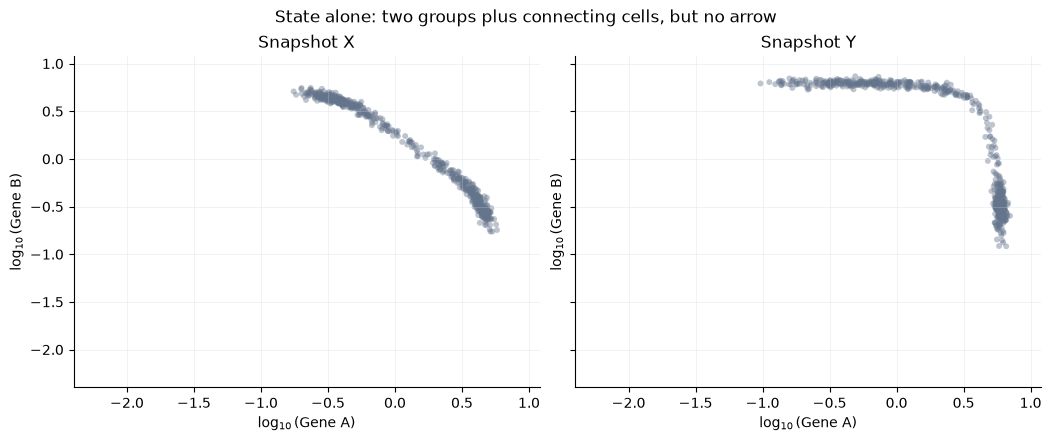

In [5]:
def plot_log_snapshot(ax, points, title):
    log_points = np.log10(points)
    ax.scatter(
        log_points[:, 0], log_points[:, 1], s=18,
        color="#64748b", alpha=0.42, edgecolor="none",
    )
    ax.set(
        title=title,
        xlabel=r"$\log_{10}$(Gene A)",
        ylabel=r"$\log_{10}$(Gene B)",
    )
    ax.set_xlim(np.log10(STATE_LIMITS))
    ax.set_ylim(np.log10(STATE_LIMITS))
    ax.grid(color="#cbd5e1", alpha=0.28, linewidth=0.7)

fig, axes = plt.subplots(
    1, 2, figsize=(10.4, 4.3), sharex=True, sharey=True,
    constrained_layout=True,
)
for ax, story, label in zip(
    axes, ("toggle", "driven"), ("Snapshot X", "Snapshot Y")
):
    plot_log_snapshot(ax, observed_snapshots[story][1], label)
fig.suptitle("State alone: two groups plus connecting cells, but no arrow")
plt.show()


### Exercise 1A — what can state alone tell you?

Looking only at Snapshot X and Snapshot Y, which explanations remain possible?

- A → B;
- B → A;
- divergence from the bridge toward two stable states;
- two groups that do not interconvert.

Freeze your answer before continuing. A continuous bridge suggests candidate paths, but can it orient those paths?


## Add one missing quantity: local velocity

Because these are simulations, we know each model's instantaneous deterministic drift $(dA/dt,dB/dt)$. We can therefore add a direction to the **same middle cells**.

On logarithmic coordinates, the displayed direction is proportional to

$$
\left(\frac{1}{A}\frac{dA}{dt},\frac{1}{B}\frac{dB}{dt}\right).
$$

We average nearby cells in bins to avoid drawing 600 overlapping arrows. The arrows are normalized, so their lengths do not encode speed. The stochastic kick that helps a B-OFF cell cross its threshold is also not shown: arrows display the deterministic part of the model at that state.


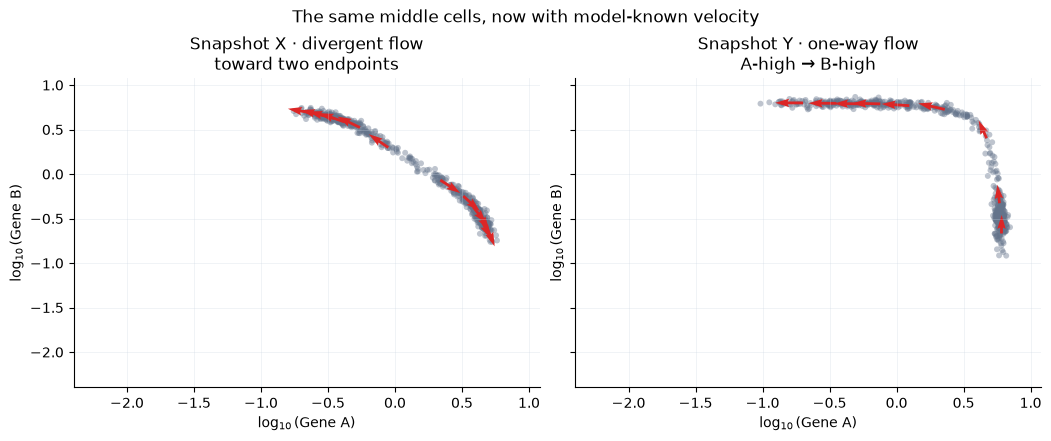

In [6]:
def representative_log_velocity(observed, latent, drift, n_bins=12):
    log_observed = np.log10(observed)
    log_velocity = drift / (
        np.maximum(latent, MIN_EXPRESSION) * np.log(10.0)
    )
    reaction_coordinate = log_observed[:, 1] - log_observed[:, 0]
    edges = np.quantile(
        reaction_coordinate, np.linspace(0.0, 1.0, n_bins + 1)
    )

    candidates = []
    for left, right in zip(edges[:-1], edges[1:]):
        mask = (
            (reaction_coordinate >= left)
            & (reaction_coordinate <= right)
        )
        if np.sum(mask) < 5:
            continue
        anchor = np.median(log_observed[mask], axis=0)
        vector = np.mean(log_velocity[mask], axis=0)
        speed = np.linalg.norm(vector)
        candidates.append((anchor, vector, speed))

    speed_cutoff = max(
        0.04, 0.12 * max(item[2] for item in candidates)
    )
    anchors = np.asarray([
        item[0] for item in candidates if item[2] >= speed_cutoff
    ])
    vectors = np.asarray([
        item[1] / item[2]
        for item in candidates if item[2] >= speed_cutoff
    ])
    return anchors, vectors

fig, axes = plt.subplots(
    1, 2, figsize=(10.4, 4.3), sharex=True, sharey=True,
    constrained_layout=True,
)
velocity_titles = (
    "Snapshot X · divergent flow\ntoward two endpoints",
    "Snapshot Y · one-way flow\nA-high → B-high",
)
for ax, story, title in zip(
    axes, ("toggle", "driven"), velocity_titles
):
    observed = observed_snapshots[story][1]
    plot_log_snapshot(ax, observed, title)
    anchors, vectors = representative_log_velocity(
        observed,
        latent_snapshots[story][1],
        snapshot_drifts[story][1],
    )
    ax.quiver(
        anchors[:, 0], anchors[:, 1],
        vectors[:, 0], vectors[:, 1],
        angles="xy", scale_units="xy", scale=4.8,
        width=0.006, color="#dc2626",
    )
fig.suptitle(
    "The same middle cells, now with model-known velocity"
)
plt.show()


### Exercise 1B — what did velocity add?

1. In which panel does the field split toward two endpoints?
2. In which panel does it carry cells from A-high/B-low toward A-low/B-high?
3. Which state-only explanations can you now reject for each simulated condition?
4. Can the arrows alone prove the exact regulatory edges drawn in the circuit cartoon? Design one perturbation that would test B self-activation or state memory.


**Worked interpretation.** The state-only middle panels support two expression regimes connected by candidate transition cells, but they do not orient the bridge. The toggle velocity splits toward A-high and B-high, whereas the driven-switch velocity moves from A-high toward B-high. For these simulations, that directional evidence rejects a reverse-only history and a disconnected-mixture explanation. It still does not uniquely prove the drawn regulatory edges: reducing the driver and then washing it out would test whether high B persists, while weakening B self-activation should remove or reduce that memory.


## What velocity can—and cannot—rule out

Without arrows, two groups joined by intermediate cells are compatible with divergence, a one-way transition, its reverse, or a disconnected mixture. Velocity supplies a **signed local direction**:

- the toggle field diverges toward two endpoints;
- the driven-switch field carries cells from A-high through the bridge toward B-high.

Under these simulated conditions, the velocity fields reject a reverse-only history and a non-interconverting mixture. A coherent one-way field also argues against a stationary symmetric toggle as the current explanation for that panel.

Velocity narrows the mechanism hypothesis space; it does not uniquely identify a molecular circuit. Hidden inputs or a different network can generate similar flow. Nor does one local field prove that an endpoint is an attractor. Perturbation followed by washout is a stronger test: return supports stability, while persistent B-high after removing the driver supports self-maintaining memory.

These arrows were available because we wrote the equations. An ordinary single-cell snapshot does not contain them.


## Where can direction come from in real data?

Real experiments can orient a candidate path using an asymmetric clue:

- ordered time points, pulse–chase sampling, or live imaging;
- lineage tracing, barcodes, or a reporter with known ordering;
- perturbation and recovery;
- a biologically justified root or known phase order;
- molecular kinetics that distinguish newly produced from mature material.

A static experiment can still capture cells at different positions along the same asynchronous process. We therefore make a useful but nontrivial assumption:

> A phenotypically nearby cell may approximate this cell's recent past or near future.

Neighbours can trace a candidate manifold or local tangent. But distance is symmetric: geometry alone cannot decide which neighbour is past and which is future. Neighbour smoothing can spread an existing directional clue; it cannot create time asymmetry from geometry alone.

The assumption can fail at branches, across hidden conditions, or when two processes overlap in the same measured coordinates.

We now examine one molecular clue that is available inside a single RNA-sequencing snapshot: precursor RNA appears before mature RNA.


# Part 2 — A molecular clock hidden inside one snapshot

In eukaryotes, a newly transcribed RNA precursor is spliced before becoming mature RNA. For one gene, let

- $U$ = unspliced precursor RNA;
- $S$ = spliced mature RNA.

A minimal kinetic model is

$$\frac{dU}{dt}=\alpha(t)-\beta U,\qquad
\frac{dS}{dt}=\beta U-\gamma S.$$

The ordering precursor → mature breaks time-reversal symmetry. If $U$ is high relative to the fitted reference, mature RNA tends to be increasing; after transcription turns off, $U$ falls first while mature RNA can remain high.

In the simulation below, parameters are known because we set them. In real data, $U$ and $S$ are measured, while kinetic parameters and derivatives must be estimated under assumptions.


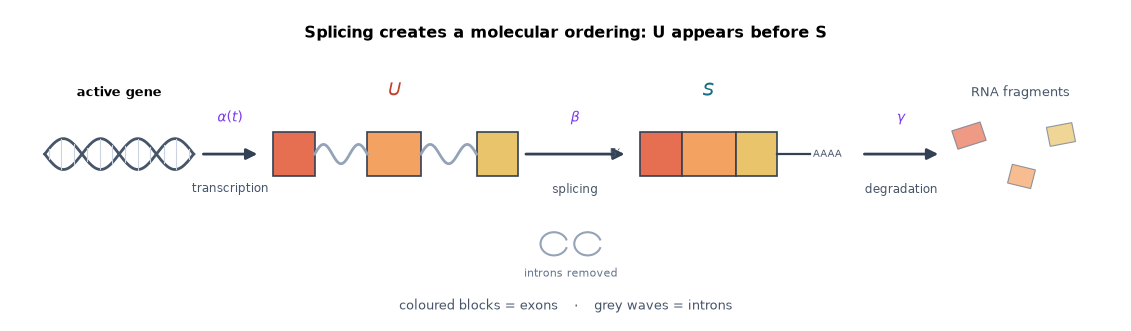

In [7]:
from matplotlib.patches import Arc, FancyArrowPatch, Rectangle

EXON_COLORS = ("#e76f51", "#f4a261", "#e9c46a")
INTRON_COLOR = "#94a3b8"

def draw_exon(ax, x, y, width, color):
    ax.add_patch(Rectangle(
        (x, y - 0.23), width, 0.46,
        facecolor=color, edgecolor="#334155", linewidth=1.2,
    ))

def draw_intron(ax, start, end, y):
    x = np.linspace(start, end, 90)
    phase = np.linspace(0.0, 3.0 * np.pi, len(x))
    ax.plot(x, y + 0.10 * np.sin(phase),
            color=INTRON_COLOR, linewidth=2.0)

def draw_process_arrow(ax, start, end, rate, process):
    ax.add_patch(FancyArrowPatch(
        start, end, arrowstyle="-|>", mutation_scale=16,
        linewidth=2.0, color="#334155",
    ))
    midpoint = ((start[0] + end[0]) / 2, start[1] + 0.30)
    ax.text(*midpoint, rate, ha="center", va="bottom",
            fontsize=10, weight="bold", color="#7c3aed")
    ax.text(midpoint[0], start[1] - 0.30, process,
            ha="center", va="top", fontsize=8.5, color="#475569")

fig, ax = plt.subplots(figsize=(11.2, 3.2), constrained_layout=True)
y = 1.55

# Active DNA: two strands with short base-pair links.
dna_x = np.linspace(0.35, 1.85, 180)
dna_phase = np.linspace(0.0, 4.0 * np.pi, len(dna_x))
upper = y + 0.16 * np.sin(dna_phase)
lower = y - 0.16 * np.sin(dna_phase)
ax.plot(dna_x, upper, color="#475569", linewidth=2.0)
ax.plot(dna_x, lower, color="#475569", linewidth=2.0)
for index in np.linspace(5, len(dna_x) - 6, 12, dtype=int):
    ax.plot([dna_x[index], dna_x[index]],
            [lower[index], upper[index]],
            color="#cbd5e1", linewidth=0.8)
ax.text(1.10, 2.15, "active gene", ha="center",
        fontsize=9.5, weight="bold")

# U: exon blocks remain separated by intron segments.
precursor_exons = [
    (2.65, 0.42, EXON_COLORS[0]),
    (3.60, 0.54, EXON_COLORS[1]),
    (4.70, 0.42, EXON_COLORS[2]),
]
for x, width, color in precursor_exons:
    draw_exon(ax, x, y, width, color)
draw_intron(ax, 3.07, 3.60, y)
draw_intron(ax, 4.14, 4.70, y)
ax.text(3.88, 2.15, r"$U$", ha="center",
        fontsize=13, weight="bold", color="#c2412d")

# S: the same exon blocks are joined after intron removal.
mature_exons = [
    (6.35, 0.42, EXON_COLORS[0]),
    (6.77, 0.54, EXON_COLORS[1]),
    (7.31, 0.42, EXON_COLORS[2]),
]
for x, width, color in mature_exons:
    draw_exon(ax, x, y, width, color)
ax.text(6.15, y, "5′", ha="right", va="center",
        fontsize=8.5, color="#475569")
ax.plot([7.73, 8.06], [y, y], color="#334155", linewidth=1.6)
ax.text(8.09, y, "AAAA", ha="left", va="center",
        fontsize=7.5, color="#475569")
ax.text(7.04, 2.15, r"$S$", ha="center",
        fontsize=13, weight="bold", color="#176b87")

# Removed introns and degraded RNA fragments.
for center in (5.48, 5.82):
    ax.add_patch(Arc(
        (center, 0.62), 0.27, 0.24, angle=0,
        theta1=15, theta2=345, color=INTRON_COLOR, linewidth=1.5,
    ))
ax.text(5.65, 0.28, "introns removed", ha="center",
        fontsize=8.2, color="#64748b")
fragment_specs = [
    (9.55, 1.70, 0.30, EXON_COLORS[0], 18),
    (10.05, 1.35, 0.24, EXON_COLORS[1], -14),
    (10.48, 1.73, 0.26, EXON_COLORS[2], 11),
]
for x, fragment_y, width, color, angle in fragment_specs:
    ax.add_patch(Rectangle(
        (x, fragment_y - 0.10), width, 0.20, angle=angle,
        facecolor=color, edgecolor="#64748b", linewidth=0.8,
        alpha=0.70,
    ))
ax.text(10.18, 2.15, "RNA fragments", ha="center",
        fontsize=9.0, color="#475569")

draw_process_arrow(ax, (1.92, y), (2.52, y),
                   r"$\alpha(t)$", "transcription")
draw_process_arrow(ax, (5.17, y), (6.22, y),
                   r"$\beta$", "splicing")
draw_process_arrow(ax, (8.58, y), (9.38, y),
                   r"$\gamma$", "degradation")

ax.text(
    5.6, 2.80,
    "Splicing creates a molecular ordering: U appears before S",
    ha="center", va="center", fontsize=11.5, weight="bold",
)
ax.text(
    5.6, -0.02,
    "coloured blocks = exons    ·    grey waves = introns",
    ha="center", va="center", fontsize=9.3, color="#475569",
)
ax.set(xlim=(0.0, 11.2), ylim=(-0.18, 3.05))
ax.axis("off")
plt.show()


In [23]:
from matplotlib.colors import LinearSegmentedColormap

TIME_CMAP = LinearSegmentedColormap.from_list(
    "bright_time",
    ["#f6df45", "#f5a65b", "#e88bc4", "#66c2e5"],
)

def simulate_splicing(alpha=7.0, beta=1.2, gamma=0.45,
                      switch_on=2.0, switch_off=10.0,
                      t_end=18.0, dt=0.01):
    time = np.arange(0.0, t_end + dt, dt)
    unspliced = np.zeros_like(time)
    spliced = np.zeros_like(time)
    transcription = np.where(
        (time >= switch_on) & (time < switch_off), alpha, 0.0
    )
    for step in range(1, len(time)):
        du = transcription[step - 1] - beta * unspliced[step - 1]
        ds = beta * unspliced[step - 1] - gamma * spliced[step - 1]
        unspliced[step] = max(0.0, unspliced[step - 1] + dt * du)
        spliced[step] = max(0.0, spliced[step - 1] + dt * ds)
    return time, unspliced, spliced, transcription

# Fixed across all slider settings
TIME_LIMITS = (0.0, 18.0)
RNA_LIMITS = (0.0, 30.0)
UNSPLICED_LIMITS = (0.0, 20.0)
SPLICED_LIMITS = (0.0, 30.0)


def plot_splicing_clock(alpha=7.0, beta=1.2, gamma=0.45,
                        switch_off=10.0, show_arrows=True):
    time, unspliced, spliced, transcription = simulate_splicing(
        alpha=alpha,
        beta=beta,
        gamma=gamma,
        switch_off=switch_off,
    )

    du = transcription - beta * unspliced
    ds = beta * unspliced - gamma * spliced

    fig, axes = plt.subplots(
        1, 2, figsize=(10.8, 4.0), constrained_layout=True
    )

    # Time-course panel
    axes[0].plot(
        time, unspliced,
        color="#e76f51", lw=2.3,
        label="unspliced U",
    )
    axes[0].plot(
        time, spliced,
        color="#277da1", lw=2.3,
        label="spliced S",
    )
    axes[0].axvspan(
        2.0, switch_off,
        color="#f4a261", alpha=0.14,
        label="transcription ON",
    )
    axes[0].set(
        xlabel="time",
        ylabel="RNA abundance",
        title="A gene turns on, then off",
        xlim=TIME_LIMITS,
        ylim=RNA_LIMITS,
    )
    axes[0].legend(frameon=False, fontsize=9)

    # State-space panel
    points = axes[1].scatter(
        unspliced,
        spliced,
        c=time,
        cmap=TIME_CMAP,
        vmin=TIME_LIMITS[0],
        vmax=TIME_LIMITS[1],
        s=11,
        alpha=0.88,
        edgecolors="none",
    )

    # The reference line now uses the fixed U-axis range
    line_u = np.linspace(
        UNSPLICED_LIMITS[0],
        UNSPLICED_LIMITS[1],
        200,
    )
    axes[1].plot(
        line_u,
        (beta / gamma) * line_u,
        "--",
        color="#64748b",
        lw=1.5,
        label="dS/dt = 0",
    )

    if show_arrows:
        arrow_index = np.linspace(
            40, len(time) - 40, 24, dtype=int
        )
        field = np.column_stack([
            du[arrow_index],
            ds[arrow_index],
        ])
        field /= np.maximum(
            np.linalg.norm(field, axis=1, keepdims=True),
            1e-9,
        )

        axes[1].quiver(
            unspliced[arrow_index],
            spliced[arrow_index],
            field[:, 0],
            field[:, 1],
            angles="xy",
            scale_units="xy",
            scale=2.3,
            width=0.006,
            color="#111827",
            alpha=0.72,
        )

    axes[1].set(
        xlabel="unspliced U",
        ylabel="spliced S",
        title="The same process in state space",
        xlim=UNSPLICED_LIMITS,
        ylim=SPLICED_LIMITS,
    )
    axes[1].legend(frameon=False, fontsize=9)

    fig.colorbar(
        points,
        ax=axes[1],
        label="true time (simulation only)",
    )

    plt.show()
    plt.close(fig)

splicing_controls = {
    "alpha": widgets.FloatSlider(
        value=4.5, min=2.0, max=12.0, step=0.5,
        description="transcription α",
    ),
    "beta": widgets.FloatSlider(
        value=1.0, min=0.3, max=2.5, step=0.1,
        description="splicing β",
    ),
    "gamma": widgets.FloatSlider(
        value=0.5, min=0.15, max=1.2, step=0.05,
        description="decay γ",
    ),
    "switch_off": widgets.FloatSlider(
        value=10.0, min=5.0, max=14.0, step=0.5,
        description="OFF time",
    ),
    "show_arrows": widgets.Checkbox(
        value=True, description="show model arrows"
    ),
}
splicing_output = stable_interactive_output(
    plot_splicing_clock, splicing_controls
)
display(widgets.VBox(list(splicing_controls.values()) + [splicing_output]))


### Exercise 2 — measured, inferred, assumed

Try three changes before answering:

1. Increase splicing rate $\beta$. What happens to the delay between U and S?
2. Decrease degradation rate $\gamma$. What happens to mature RNA memory?
3. Hide the arrows. Why does the same curved trajectory permit both forward and reverse stories?

Complete these statements:

- **Measured in a real experiment:** `...`
- **Inferred by the kinetic model:** `...`
- **Assumed when transferring local directions between cells:** `...`

The important lesson is not that RNA processing gives perfect ground truth. It supplies a biologically motivated asymmetry that a model can test and propagate over a neighbourhood graph.


**Worked interpretation.** Increasing $\beta$ transfers precursor RNA into mature RNA more quickly, reducing the U-before-S delay. Decreasing $\gamma$ lengthens mature-RNA memory after transcription falls. A curve in $(U,S)$ space has no arrow unless time, kinetics, or another asymmetric observation orients it. Real experiments measure U and S counts; the model infers kinetic parameters and derivatives; transferring directions across cells assumes nearby phenotypes sample a shared process and that omitted variables do not reverse it.


# Part 3 — Recover a candidate velocity from real U2OS data

We now move directly from the simulated splicing clock to real data.
The source experiment measured 1,152 asynchronous cells from the same
U2OS-FUCCI cell line by SMART-seq2. After phase-blind QC, the teaching
object contains **1,141 cells and all 15,616 QC-passing genes**.

For every retained cell and gene it provides:

- jointly depth-normalized spliced abundance $S$;
- jointly depth-normalized unspliced abundance $U$;
- $\log(1+S)$ in `.X` for state-space PCA.

It contains no fitted velocity, neighbour graph, PCA coordinates,
FUCCI value, phase label, or author-selected cell-cycle gene list.
Those are either constructed below or held out until the final audit.

**Data source:** [Mahdessian et al., *Nature* (2021)](https://www.nature.com/articles/s41586-021-03232-9);
[GEO GSE146773](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE146773).


In [9]:
from scipy import sparse
from sklearn.neighbors import NearestNeighbors

adata = ad.read_h5ad(BLIND_H5AD)
assert adata.shape == (1141, 15616)
assert {"spliced", "unspliced"}.issubset(adata.layers)
assert "residual_velocity" not in adata.layers
assert len(adata.obsm) == 0 and len(adata.obsp) == 0
forbidden = [
    name for name in adata.obs.columns
    if "fucci" in name.lower() or "phase" in name.lower()
]
assert forbidden == []

S = adata.layers["spliced"].tocsr()
U = adata.layers["unspliced"].tocsr()
normalized_total = np.asarray((S + U).sum(axis=1)).ravel()
np.testing.assert_allclose(normalized_total, 10_000, rtol=2e-5, atol=0.1)

print(f"Blind data: {adata.n_obs:,} cells × {adata.n_vars:,} all-QC genes")
print("Measured-derived inputs available now: normalized S and U")
print("Precomputed velocity/graph/FUCCI fields:", [])


Blind data: 1,141 cells × 15,616 all-QC genes
Measured-derived inputs available now: normalized S and U
Precomputed velocity/graph/FUCCI fields: []


## Step 1 — define local replicate groups without phase labels

Fit 30-dimensional PCA using **all QC genes** in $\log(1+S)$, then
find the 10 nearest cells for each cell in that PCA space. PCA supplies
an undirected state geometry; it does not supply time or velocity.

In this asynchronous cell line, nearby transcriptomes can be treated
as approximate replicate observations of the same local cell-cycle
state. Averaging their $S/U$ values estimates a local population mean:

$$
\bar S_i=\sum_j w_{ij}S_j,\qquad
\bar U_i=\sum_j w_{ij}U_j.
$$

If rapid transcriptional bursts and sampling fluctuations are
unsynchronised across these otherwise similar cells, averaging can
reveal the slower systematic trend underneath. It is not a movie of
one cell, and a neighbourhood has no direction by itself.

**Ask your AI coach:** help you fit PCA30 and construct one sparse
averaging matrix containing each focal cell plus its 10 neighbours.
Do not load FUCCI.


In [10]:
expression = adata.X.toarray().astype(np.float32, copy=False)
pca_model = PCA(
    n_components=30,
    svd_solver="randomized",
    random_state=SEED,
)
state_pca = pca_model.fit_transform(expression).astype(np.float32)
del expression

# Querying the training data returns the focal cell plus 10 others.
neighbor_model = NearestNeighbors(n_neighbors=11, metric="euclidean")
neighbor_model.fit(state_pca)
neighbor_indices = neighbor_model.kneighbors(
    state_pca, return_distance=False
)
rows = np.repeat(np.arange(adata.n_obs), neighbor_indices.shape[1])
cols = neighbor_indices.ravel()
weights = np.full(
    len(rows), 1.0 / neighbor_indices.shape[1], dtype=np.float32
)
W = sparse.csr_matrix(
    (weights, (rows, cols)),
    shape=(adata.n_obs, adata.n_obs),
)
np.testing.assert_allclose(
    np.asarray(W.sum(axis=1)).ravel(), 1.0, atol=1e-6
)
print("PCA shape:", state_pca.shape)
print("Local mean uses focal cell + 10 neighbours.")
print(
    "PC1–PC3 explained variance:",
    ", ".join(
        f"{100*x:.2f}%"
        for x in pca_model.explained_variance_ratio_[:3]
    ),
)


PCA shape: (1141, 30)
Local mean uses focal cell + 10 neighbours.
PC1–PC3 explained variance: 6.99%, 2.94%, 2.45%


## Step 2 — one gene before and after neighbour averaging

Start with **CENPF**, a kinetochore-associated cell-cycle gene whose
abundance rises through S/G2 and is high around G2/M. It is useful here
because individual-cell $S/U$ values are visibly noisy, while its
local-mean portrait is more structured. You may replace it with
`TOP2A`, `CCNB1`, or another biologically justified choice.

Plot two panels on the same linear, normalized scale:

1. one point per cell using raw normalized $(S,U)$;
2. one point per cell using neighbour means $(\bar S,\bar U)$.

Keep FUCCI sealed. The structure should come from RNA, not from a
phase label. CENPF background:
[Liao et al.](https://pmc.ncbi.nlm.nih.gov/articles/PMC2120529/).


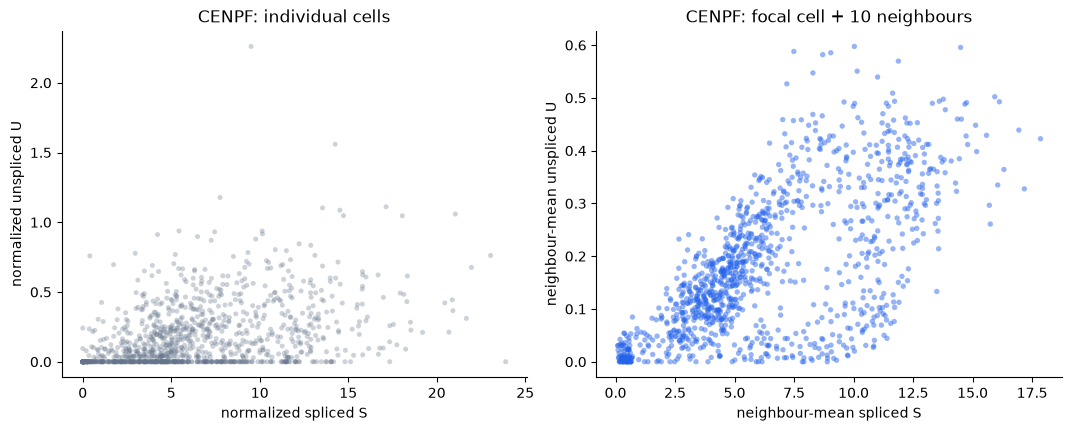

Raw S/U correlation: 0.401
Local-mean S/U correlation: 0.660


In [11]:
def gene_index_for(symbol):
    symbols = adata.var["gene_symbol"].astype(str).to_numpy()
    matches = np.flatnonzero(symbols == symbol)
    if not len(matches):
        raise KeyError(f"{symbol} is absent after QC")
    return int(matches[0])

GENE = "CENPF"
gene_index = gene_index_for(GENE)
s_raw = np.asarray(S[:, gene_index].toarray()).ravel()
u_raw = np.asarray(U[:, gene_index].toarray()).ravel()
s_bar = np.asarray((W @ S[:, gene_index]).toarray()).ravel()
u_bar = np.asarray((W @ U[:, gene_index]).toarray()).ravel()

fig, axes = plt.subplots(
    1, 2, figsize=(10.6, 4.2), constrained_layout=True
)
axes[0].scatter(
    s_raw, u_raw, s=13, alpha=0.32,
    color="#64748b", edgecolor="none",
)
axes[1].scatter(
    s_bar, u_bar, s=15, alpha=0.48,
    color="#2563eb", edgecolor="none",
)
axes[0].set(
    xlabel="normalized spliced S",
    ylabel="normalized unspliced U",
    title=f"{GENE}: individual cells",
)
axes[1].set(
    xlabel="neighbour-mean spliced S",
    ylabel="neighbour-mean unspliced U",
    title=f"{GENE}: focal cell + 10 neighbours",
)
plt.show()

raw_corr = np.corrcoef(s_raw, u_raw)[0, 1]
smooth_corr = np.corrcoef(s_bar, u_bar)[0, 1]
print(f"Raw S/U correlation: {raw_corr:.3f}")
print(f"Local-mean S/U correlation: {smooth_corr:.3f}")


### Check the averaging assumption

In this U2OS cell-line example, the approximation is fairly plausible:
the cells share a genetic background and culture condition, and the
neighbourhood is deliberately local. Still, compare 5, 10, and 20
neighbours. A pattern that changes completely with $k$ is not robust.

**Think before continuing:** did averaging create new time information?
Or did it estimate a less noisy conditional mean using an undirected
state graph?


## Step 3 — fit an empirical $U/S$ reference

For a transparent first attempt, take the most active 20% of cells for
this gene and fit a line through the origin:

$$
\bar U\approx r\bar S,\qquad
q_i=\bar U_i-r\bar S_i.
$$

We call this an **empirical reference line**, not a proven steady
state. In a cycling system, high expression can itself be transient.
Under the minimal equation

$$
\frac{dS}{dt}=\beta U-\gamma S
=\beta\left(U-\frac{\gamma}{\beta}S\right),
$$

$q_i>0$ supports increasing mature RNA and $q_i<0$ supports decreasing
mature RNA if $r$ approximates $\gamma/\beta$. The magnitude of $q$
is a **relative velocity score**, not a calibrated physical speed.

**Modelling question:** what did we assume by choosing the high-activity
cells, forcing the intercept to zero, and using $q$ directly as speed?
What could go wrong for a bursty gene or a gene that never approaches
the reference regime?


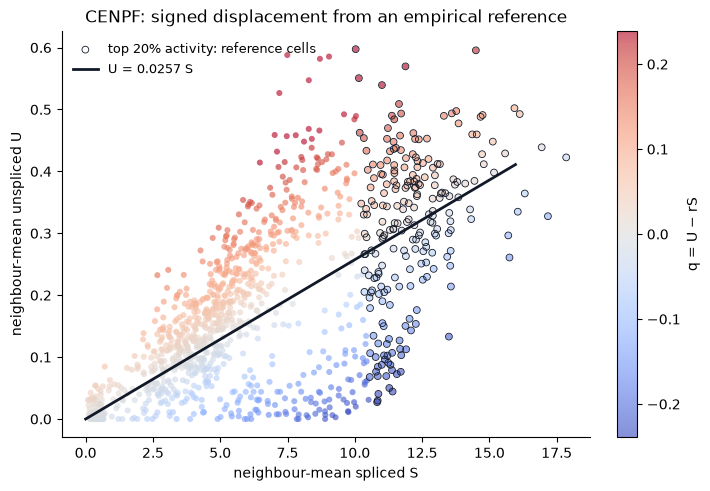

Reference slope r = 0.02574
Reference cells = 229


In [12]:
def fit_origin_reference(s, u, upper_quantile=0.80):
    activity = s + u
    active = (activity > 0) & (s > 0)
    if active.sum() < 20:
        raise ValueError("Too few active cells")
    threshold = np.quantile(activity[active], upper_quantile)
    fit_cells = active & (activity >= threshold)
    denominator = np.dot(s[fit_cells], s[fit_cells])
    if denominator <= 1e-12:
        raise ValueError("Reference fit has no spliced signal")
    slope = max(
        0.0,
        float(
            np.dot(s[fit_cells], u[fit_cells]) / denominator
        ),
    )
    return slope, fit_cells, u - slope * s

gene_slope, gene_fit_cells, gene_q = fit_origin_reference(s_bar, u_bar)
q_limit = max(np.quantile(np.abs(gene_q), 0.98), 1e-6)
line_s = np.linspace(0, np.quantile(s_bar, 0.995), 120)

fig, ax = plt.subplots(figsize=(7.0, 4.8), constrained_layout=True)
points = ax.scatter(
    s_bar, u_bar, c=gene_q, s=19, alpha=0.62,
    cmap="coolwarm", vmin=-q_limit, vmax=q_limit,
    edgecolor="none",
)
ax.scatter(
    s_bar[gene_fit_cells], u_bar[gene_fit_cells],
    s=24, facecolor="none", edgecolor="#111827",
    linewidth=0.6, label="top 20% activity: reference cells",
)
ax.plot(
    line_s, gene_slope * line_s,
    color="#111827", lw=2.0, label=f"U = {gene_slope:.4f} S",
)
ax.set(
    xlabel="neighbour-mean spliced S",
    ylabel="neighbour-mean unspliced U",
    title=f"{GENE}: signed displacement from an empirical reference",
)
ax.legend(frameon=False, fontsize=9)
fig.colorbar(points, ax=ax, label="q = U − rS")
plt.show()
print(f"Reference slope r = {gene_slope:.5f}")
print(f"Reference cells = {gene_fit_cells.sum()}")


## Step 4 — repeat the simple model across genes

Apply the same calculation to every gene with enough active cells.
Keep unreliable genes marked as **missing**; do not silently invent
their velocity. For PCA coordinates built from
$x_g=\log(1+S_g)$, use the chain rule before projection:

$$
v^{(\log S)}_{ig}\propto
\frac{\bar U_{ig}-r_g\bar S_{ig}}{1+\bar S_{ig}},
\qquad
v_i^{(\mathrm{PCA})}
=v_i^{(\log S)}W_{\mathrm{PCA}}^\mathsf{T}.
$$

**Two questions to discuss before seeing the field**

1. Treating residual size as comparable speed across genes hides which
   assumptions about gene-specific splicing rates, capture efficiency,
   and expression scale?
2. If some genes lack a reliable $U/S$ fit, could information from
   well-fitted genes, a shared latent time, or a molecular network
   predict their change? What new assumptions would that add?


In [13]:
S_bar = (W @ S).toarray().astype(np.float32, copy=False)
U_bar = (W @ U).toarray().astype(np.float32, copy=False)

n_genes = adata.n_vars
slopes = np.full(n_genes, np.nan, dtype=np.float32)
fit_correlation = np.full(n_genes, np.nan, dtype=np.float32)
active_cells = np.zeros(n_genes, dtype=np.int32)
relative_q = np.zeros_like(S_bar, dtype=np.float32)

for gene in range(n_genes):
    s = S_bar[:, gene]
    u = U_bar[:, gene]
    activity = s + u
    active = (activity > 0) & (s > 0)
    active_cells[gene] = int(active.sum())
    if active.sum() < 50:
        continue
    threshold = np.quantile(activity[active], 0.80)
    fit_cells = active & (activity >= threshold)
    if fit_cells.sum() < 20:
        continue
    denominator = np.dot(s[fit_cells], s[fit_cells])
    if denominator <= 1e-12:
        continue
    slope = max(
        0.0,
        float(np.dot(s[fit_cells], u[fit_cells]) / denominator),
    )
    centered_s = (
        s[fit_cells].astype(np.float64)
        - np.mean(s[fit_cells], dtype=np.float64)
    )
    centered_u = (
        u[fit_cells].astype(np.float64)
        - np.mean(u[fit_cells], dtype=np.float64)
    )
    correlation_scale = (
        np.linalg.norm(centered_s)
        * np.linalg.norm(centered_u)
    )
    correlation = (
        float(np.dot(centered_s, centered_u) / correlation_scale)
        if correlation_scale > 1e-12
        else np.nan
    )
    slopes[gene] = slope
    fit_correlation[gene] = correlation
    relative_q[:, gene] = u - slope * s

candidate = (
    np.isfinite(slopes)
    & np.isfinite(fit_correlation)
    & (fit_correlation > 0.05)
    & (active_cells >= 50)
)
reliable_genes = np.flatnonzero(candidate)
if len(reliable_genes) < 40:
    raise RuntimeError("Too few genes passed the transparent fit audit")

relative_velocity_log = (
    relative_q[:, reliable_genes]
    / (1.0 + S_bar[:, reliable_genes])
)
velocity_pca = (
    relative_velocity_log
    @ pca_model.components_[:, reliable_genes].T
).astype(np.float32)

print(f"Genes with an empirical fit: {np.isfinite(slopes).sum():,}")
print(f"Genes passing the simple reliability rule: {candidate.sum():,}")
print(f"Genes used for the partial PCA field: {len(reliable_genes):,}")
print(
    "Unfitted genes remain missing; their velocity was not inferred."
)


Genes with an empirical fit: 15,520
Genes passing the simple reliability rule: 2,692
Genes used for the partial PCA field: 2,692
Unfitted genes remain missing; their velocity was not inferred.


## Step 5 — rotate the state map, then add 200 cell-level arrows

First draw PC1–PC3 without arrows and find a camera angle that reveals
the near-cyclic structure. Then sample 200 cells reproducibly and add
their projected relative-velocity arrows.

Arrow direction is the main object here; arrow length is rescaled for
display and is not a calibrated rate. Also remember that the sign of a
PCA axis is arbitrary: report biological phase order later, not merely
“clockwise” or “counter-clockwise”.


In [14]:
state_3d = state_pca[:, :3]
explained = 100 * pca_model.explained_variance_ratio_[:3]

def base_3d_layout(title):
    return dict(
        title=title,
        scene=dict(
            xaxis_title=f"PC1 ({explained[0]:.1f}%)",
            yaxis_title=f"PC2 ({explained[1]:.1f}%)",
            zaxis_title=f"PC3 ({explained[2]:.1f}%)",
            aspectmode="data",
        ),
        margin=dict(l=0, r=0, t=45, b=0),
        height=650,
    )

state_trace = go.Scatter3d(
    x=state_3d[:, 0],
    y=state_3d[:, 1],
    z=state_3d[:, 2],
    mode="markers",
    name="cells",
    marker=dict(size=3, color="#64748b", opacity=0.55),
    text=adata.obs_names,
    hovertemplate=(
        "%{text}<br>PC1=%{x:.2f}<br>PC2=%{y:.2f}"
        "<br>PC3=%{z:.2f}<extra></extra>"
    ),
)
geometry_figure = go.Figure(state_trace)
geometry_figure.update_layout(
    **base_3d_layout("U2OS state geometry from all-QC-gene PCA")
)
geometry_figure.show(config={"displaylogo": False})


In [15]:
arrow_rng = np.random.default_rng(SEED + 31)
arrow_cells = np.sort(
    arrow_rng.choice(adata.n_obs, size=200, replace=False)
)
arrow_velocity = velocity_pca[arrow_cells, :3]
arrow_norm = np.linalg.norm(arrow_velocity, axis=1)
nonzero = arrow_norm > 0
display_scale = 0.75 / max(
    np.quantile(arrow_norm[nonzero], 0.90), 1e-9
)
display_velocity = arrow_velocity * display_scale
max_length = 1.2
lengths = np.linalg.norm(display_velocity, axis=1)*4
clip = np.minimum(1.0, max_length / np.maximum(lengths, 1e-9))
display_velocity *= clip[:, None]

arrow_trace = go.Cone(
    x=state_3d[arrow_cells, 0],
    y=state_3d[arrow_cells, 1],
    z=state_3d[arrow_cells, 2],
    u=display_velocity[:, 0],
    v=display_velocity[:, 1],
    w=display_velocity[:, 2],
    anchor="tail",
    sizemode="absolute",
    sizeref=0.22,
    colorscale=[[0, "#dc2626"], [1, "#dc2626"]],
    showscale=False,
    name="relative RNA velocity",
    hovertemplate="model-derived direction<extra></extra>",
)
field_figure = go.Figure([state_trace, arrow_trace])
field_figure.update_layout(
    **base_3d_layout(
        "All-QC PCA + 200 model-derived cell-level directions"
    )
)
field_figure.show(config={"displaylogo": False})


### Freeze the blind claim

Before opening FUCCI, write down:

1. Does the RNA-derived field circulate coherently around the loop?
2. Which regions contain weak or conflicting arrows?
3. Which choices—gene reliability, neighbour number, reference cells,
   or unknown gene-specific rates—could alter the result?
4. Describe the path using locations in the plot, not only a
   screen-dependent clockwise label.


## Step 6 — reveal the independent FUCCI phase clock

FUCCI uses fluorescent protein reporters whose abundances change with
cell-cycle progression. In this U2OS line, the CDT1-associated red
reporter is strongest around G1, while the Geminin-associated green
reporter marks S/G2/M. The biological order is cyclic:

$$\mathrm{G1\rightarrow S\rightarrow G2/M\rightarrow G1}.$$

The reveal table was held out from QC, PCA, neighbour construction,
$U/S$ fitting, gene filtering, and arrow estimation. It is still a
same-cell phase proxy rather than a longitudinal movie, but it provides
a distinct measurement modality with which to audit the RNA-derived
direction.


,raw_green530,raw_red585,assigned_phase
flow_cluster,,,
0,20.0,216.0,G1
1,2009.5,10.0,G2/M
2,785.0,499.0,S


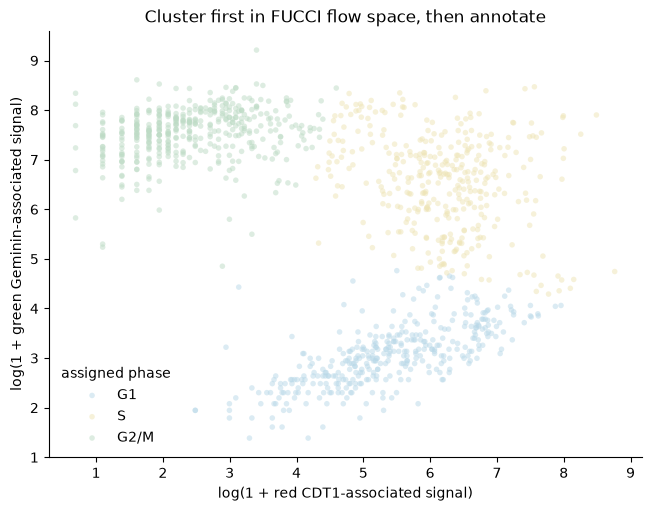

supplied FACS gate,G1,G2/M,S,All
cluster-first label,,,,
G1,343,0,0,343
G2/M,0,383,9,392
S,0,0,325,325
All,343,383,334,1060


G1      370
S       351
G2/M    418
Name: count, dtype: Int64


In [16]:
fucci = pd.read_csv(REVEAL_CSV).set_index("cell_id")
fucci = fucci.reindex(adata.obs_names)
flow_columns = ["raw_green530", "raw_red585"]
matched = fucci[flow_columns].notna().all(axis=1).to_numpy()
if matched.sum() != 1139:
    raise ValueError(
        f"Expected 1,139 matched FUCCI cells; found {matched.sum()}"
    )

# Cluster the two measured flow-cytometry channels without using
# the supplied FACS phase labels or the derived FUCCI time.
flow_log = np.log1p(
    fucci.loc[matched, flow_columns].to_numpy(dtype=float)
)
flow_scaled = StandardScaler().fit_transform(flow_log)
flow_model = KMeans(
    n_clusters=3, random_state=SEED, n_init=50
)
flow_cluster = pd.Series(
    pd.NA, index=fucci.index, dtype="Int64"
)
flow_cluster.loc[matched] = flow_model.fit_predict(flow_scaled)

cluster_summary = (
    fucci.loc[matched, flow_columns]
    .assign(
        flow_cluster=flow_cluster.loc[matched]
        .astype(int)
        .to_numpy()
    )
    .groupby("flow_cluster")[flow_columns]
    .median()
)

# Annotate only after clustering, using FUCCI biology:
# red-only is G1, red+green is S, and green-only is G2/M.
g1_cluster = int(cluster_summary["raw_green530"].idxmin())
remaining = [
    cluster for cluster in cluster_summary.index
    if cluster != g1_cluster
]
g2m_cluster = int(
    cluster_summary.loc[remaining, "raw_red585"].idxmin()
)
s_cluster = int(
    next(
        cluster for cluster in remaining
        if cluster != g2m_cluster
    )
)
phase_map = {
    g1_cluster: "G1",
    s_cluster: "S",
    g2m_cluster: "G2/M",
}
cluster_summary["assigned_phase"] = pd.Series(phase_map)
display(cluster_summary)

phase_by_flow = pd.Series(
    pd.NA, index=fucci.index, dtype="string"
)
phase_by_flow.loc[matched] = (
    flow_cluster.loc[matched].astype(int).map(phase_map)
)
phase_order = ["G1", "S", "G2/M"]
phase_colors = {
    "G1": "#b8d8e8",
    "S": "#eee4b5",
    "G2/M": "#bddbc5",
}

fig, ax = plt.subplots(
    figsize=(6.4, 5.0), constrained_layout=True
)
for phase in phase_order:
    phase_mask = (
        matched
        & phase_by_flow.eq(phase).fillna(False).to_numpy()
    )
    ax.scatter(
        np.log1p(fucci.loc[phase_mask, "raw_red585"]),
        np.log1p(fucci.loc[phase_mask, "raw_green530"]),
        s=16, alpha=0.50, edgecolor="none",
        color=phase_colors[phase], label=phase,
    )
ax.set(
    xlabel="log(1 + red CDT1-associated signal)",
    ylabel="log(1 + green Geminin-associated signal)",
    title="Cluster first in FUCCI flow space, then annotate",
)
ax.legend(title="assigned phase", frameon=False)
plt.show()

fucci_traces = []
for phase in phase_order:
    phase_mask = (
        matched
        & phase_by_flow.eq(phase).fillna(False).to_numpy()
    )
    customdata = np.column_stack([
        fucci.loc[phase_mask, "raw_red585"],
        fucci.loc[phase_mask, "raw_green530"],
    ])
    fucci_traces.append(go.Scatter3d(
        x=state_3d[phase_mask, 0],
        y=state_3d[phase_mask, 1],
        z=state_3d[phase_mask, 2],
        mode="markers",
        name=f"flow-clustered {phase}",
        marker=dict(
            size=3.4,
            color=phase_colors[phase],
            opacity=0.76,
        ),
        customdata=customdata,
        hovertemplate=(
            f"assigned phase={phase}"
            "<br>red=%{customdata[0]:.0f}"
            "<br>green=%{customdata[1]:.0f}"
            "<extra></extra>"
        ),
    ))

fucci_figure = go.Figure(fucci_traces + [arrow_trace])
fucci_figure.update_layout(
    **base_3d_layout(
        "Flow-clustered FUCCI phases + blind RNA-derived field"
    )
)
fucci_figure.show(config={"displaylogo": False})

# Only after freezing the cluster-based annotation, compare it
# with the supplied FACS gates as an audit.
supplied_phase = fucci["phase_by_facs_gating"].replace({
    "S-ph": "S",
    "G2M": "G2/M",
})
display(pd.crosstab(
    phase_by_flow.loc[matched],
    supplied_phase.loc[matched],
    rownames=["cluster-first label"],
    colnames=["supplied FACS gate"],
    margins=True,
))
print(
    phase_by_flow.loc[matched]
    .value_counts()
    .reindex(phase_order)
)


## From velocity to mechanism: what level have we reached?

A velocity field is already more than clustering: it proposes a local
state-transition rule. It can seed a coarse-grained transition model,
for example a Markov model that assigns higher probability to nearby
states aligned with the arrows. Such a model can predict population
flow and candidate future states.

That is a **state-level or phenomenological mechanism**. It does not
yet identify which molecular interactions generate the flow. For
intervention, a deeper target is a falsifiable molecular model,

$$
\frac{dx}{dt}=f(x,\text{regulatory network},\text{drug or perturbation}),
$$

that explains the observed cycle and predicts how a gene knockdown or
drug changes it. This matters because many practical interventions act
on molecules, not on an abstract cell-state coordinate.

**Open mechanism challenge**

- Can known cell-cycle regulators and molecular-interaction priors be
  reduced to a small dynamical model that reproduces the observed
  expression order and velocity?
- Which off-ring cells are technical outliers, transient responses,
  damaged/arrested cells, or evidence that the model omits a variable?
- Which perturbation would most clearly distinguish two candidate
  molecular explanations?

A final measurement caveat: RNA-seq measures RNA abundance, not protein
abundance or protein production rate. Translation and protein
degradation add another dynamical layer. Here, $\log(1+S)$ is the
observed RNA state, while unspliced RNA supplies a model-dependent clue
to the rate of change of mature RNA.


## U2OS deliverable

Submit three linked panels and four sentences:

1. raw versus 10-neighbour-mean CENPF $S/U$;
2. draggable all-QC PC1–PC3 state geometry with 200 arrows;
3. the same geometry and arrows colored by held-out FUCCI;
4. one sentence each for **measured state**, **inferred velocity**,
   **independent audit**, and **remaining molecular-mechanism question**.

More elaborate algorithms may fit full kinetic parameters or learn a
continuous field with machine learning. Their details differ, but
direction still has to enter through asymmetric biological information,
modelling assumptions, or an external clock.


**Worked interpretation.** Neighbour averaging makes the CENPF
phase portrait more coherent because it estimates a local
population mean from cells in similar transcriptomic states.
It reduces rapid, unsynchronised fluctuations but does not add
direction: the fitted $U/S$ reference supplies the signed
kinetic assumption. The resulting partial transcriptome field
circulates around much of the all-gene PCA loop, and the
held-out FUCCI phase order provides the stronger orientation
check. Agreement supports a useful candidate flow, while
uncertainty in per-gene kinetics, neighbourhoods, and off-ring
cells prevents it from being a complete molecular mechanism.


# Part 4 — Free exploration: human CD34+ bone marrow

After the guided cell-cycle exercise, apply the same evidence discipline
to a harder branching system. The supplied blind object contains 5,780
human CD34+ bone-marrow cells and 14,319 genes with spliced and
unspliced counts. It contains no donor time course, lineage tracing,
protein panel, cluster label, pseudotime, or supplied embedding.

**Source:** [Setty et al., *Nature Biotechnology* (2019)](https://doi.org/10.1038/s41587-019-0068-4);
[processed dataset](https://doi.org/10.6084/m9.figshare.14465559).
You may instead propose another small public dataset, but record its
provenance and what supplies its arrow of time.


In [17]:
cd34 = ad.read_h5ad(CD34_H5AD)
assert cd34.shape == (5780, 14319)
assert {"spliced", "unspliced"}.issubset(cd34.layers)
print(cd34)
print("Reference labels and pseudotime remain sealed.")


AnnData object with n_obs × n_vars = 5780 × 14319
    uns: 'information_firewall', 'source'
    layers: 'spliced', 'unspliced'
Reference labels and pseudotime remain sealed.


## Research brief

With an AI collaborator, produce one defensible cell-state-shifting
hypothesis:

1. normalize the data and construct a state map;
2. identify candidate regions using coordinated marker programmes;
3. state exactly what orients each proposed branch;
4. inspect several genes' raw and local-mean $S/U$ portraits;
5. test sensitivity to gene selection and neighbour number;
6. freeze your claim, then compare it with the sealed reference table;
7. propose one independent experiment and one molecular mechanism that
   could explain or falsify the transition.

In this branching dataset, neighbour averaging needs greater care than
in U2OS: do not average across lineage branches merely because a
low-dimensional projection places them close together.


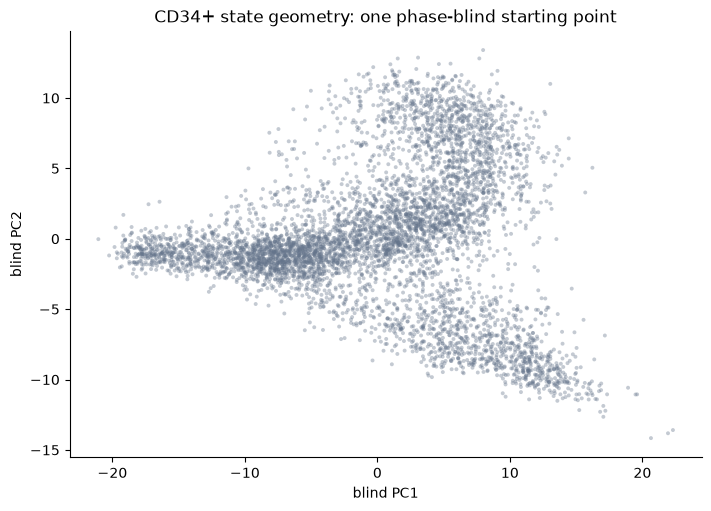

Continue with marker programmes, branch-aware neighbours, gene-level S/U audits, and a frozen claim before reveal.


In [18]:
# One possible starting point, not a unique solution:
cd34_s = cd34.layers["spliced"].tocsr().astype(np.float32)
cd34_u = cd34.layers["unspliced"].tocsr().astype(np.float32)
cd34_depth = np.asarray((cd34_s + cd34_u).sum(axis=1)).ravel()
cd34_scale = 1e4 / np.maximum(cd34_depth, 1.0)
cd34_log_s = cd34_s.multiply(cd34_scale[:, None]).tocsr()
cd34_log_s.data = np.log1p(cd34_log_s.data)

mean = np.asarray(cd34_log_s.mean(axis=0)).ravel()
mean_sq = np.asarray(cd34_log_s.power(2).mean(axis=0)).ravel()
variance = np.maximum(mean_sq - mean**2, 0.0)
expressed = np.flatnonzero(mean > 0)
selected = expressed[np.argsort(variance[expressed])[-2000:]]
cd34_pca_model = PCA(
    n_components=20,
    svd_solver="randomized",
    random_state=SEED,
)
cd34_pca = cd34_pca_model.fit_transform(
    cd34_log_s[:, selected].toarray().astype(np.float32)
)

fig, ax = plt.subplots(figsize=(7.0, 5.0), constrained_layout=True)
ax.scatter(
    cd34_pca[:, 0], cd34_pca[:, 1],
    s=8, alpha=0.38, color="#64748b", edgecolor="none",
)
ax.set(
    xlabel="blind PC1", ylabel="blind PC2",
    title="CD34+ state geometry: one phase-blind starting point",
)
plt.show()
print(
    "Continue with marker programmes, branch-aware neighbours, "
    "gene-level S/U audits, and a frozen claim before reveal."
)


A useful marker starting panel is `CD34`/`THY1` (early),
`GATA1`/`HBB` (erythroid), `MPO`/`LYZ`/`CSF1R` (myeloid),
`CD79B`/`EBF1` (lymphoid progenitor), `IRF8` (dendritic), and
`ITGA2B`/`PF4` (megakaryocyte). Treat coordinated programmes as
biological prior evidence, not experimental ancestry labels.

When ready, load `CD34_REVEAL_CSV`. Its cluster labels and pseudotime
are previous computations, not ground truth; disagreement is a prompt
to audit assumptions rather than an automatic failure.
